# A) Stage4(이벤트/트레이드 기반) 분석 (정리본)

목표
- `runs/<run_id>/specs/stage4_summary.json`에서 **수식/조합/임계값(threshold)**과 **성과(특히 excess IR)**, **benchmark**를 일괄 로드
- run별/outer_iter별로 결과를 표 형태(`combo_df`, `thr_df`)로 정리
- 원하는 run/combo를 골라 **저장된 artifacts(trades/report)**로 자세히 보기

지원 스키마(혼재 가능)
- `backtest_mode=per_combo_parallel` : `all_combinations[*]`에 성과/threshold 같이 있음
- `backtest_mode=combined_or` :
  - 개별 combo threshold는 `combo_thresholds[*].optimal_thresholds`
  - combined_or 성과는 `all_combinations[0]` (combo_idx="combined_or")
- (old) `qlib` 계열: `qlib_artifacts/iter_*/qlib_res.csv`가 있으면 그걸 우선 사용

주의
- `threshold`는 **(0~1) 분위수 값**이고, 티커별 실제 컷값은 IS에서 다시 계산해야 함.


In [1]:
from __future__ import annotations

from pathlib import Path
import json
import pickle

import numpy as np
import pandas as pd


def _find_project_root(start: Path) -> Path:
    start = start.resolve()

    # If the notebook is launched from a higher-level directory (e.g. /home/dgu/fin),
    # prefer the child project folder when it exists.
    if (start / "runs").exists():
        return start
    if (start / "01_15_new_qlib" / "runs").exists():
        return start / "01_15_new_qlib"

    # Otherwise search upwards.
    for p in start.parents:
        if (p / "runs").exists():
            return p
        if (p / "01_15_new_qlib" / "runs").exists():
            return p / "01_15_new_qlib"

    return start


ROOT = _find_project_root(Path.cwd())
RUNS_DIR = ROOT / "runs"

print("ROOT:", ROOT)
print("RUNS_DIR exists?", RUNS_DIR.exists(), RUNS_DIR)


ROOT: /home/dgu/fin/01_15_new_qlib
RUNS_DIR exists? True /home/dgu/fin/01_15_new_qlib/runs


## 1) 공통 유틸 (JSON 로드 / outer_iter 처리 / 스키마 어댑터)


In [2]:
def read_json(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def iter_run_dirs(runs_dir: Path) -> list[Path]:
    if not runs_dir.exists():
        return []
    out = []
    for p in runs_dir.iterdir():
        if p.is_dir() and p.name[:8].isdigit():
            out.append(p)
    return sorted(out, key=lambda x: x.name)


def iter_stage4_payloads(stage4_obj: dict):
    """Yield (outer_iter:int|None, payload:dict)."""
    if isinstance(stage4_obj, dict):
        keys = [k for k in stage4_obj.keys() if isinstance(k, str) and k.startswith("outer_iter_")]
        if keys:
            for k in sorted(keys, key=lambda s: int(s.split("_")[-1])):
                yield int(k.split("_")[-1]), stage4_obj[k]
            return
    yield None, stage4_obj


def pick_stage4_payload(stage4_obj: dict, outer_iter_mode="latest"):
    """Return a list of (outer_iter, payload) according to outer_iter_mode."""
    payloads = list(iter_stage4_payloads(stage4_obj))
    if not payloads:
        return []

    if outer_iter_mode == "all":
        return payloads

    if outer_iter_mode == "latest":
        best = None
        for oi, pl in payloads:
            key = -1 if oi is None else int(oi)
            if best is None or key > best[0]:
                best = (key, (oi, pl))
        return [best[1]]

    if isinstance(outer_iter_mode, int):
        for oi, pl in payloads:
            if oi == outer_iter_mode:
                return [(oi, pl)]
        return []

    raise ValueError("outer_iter_mode must be 'latest', 'all', or int")


def get_nested(d, *keys, default=np.nan):
    cur = d
    for k in keys:
        if not isinstance(cur, dict) or k not in cur:
            return default
        cur = cur[k]
    return cur


def try_read_csv(path: Path) -> pd.DataFrame | None:
    if not path.exists():
        return None
    try:
        return pd.read_csv(path)
    except Exception:
        return None


def find_qlib_res(run_dir: Path) -> pd.DataFrame | None:
    """Return qlib_res.csv if present under qlib_artifacts/iter_*/."""
    qlib_art = run_dir / "qlib_artifacts"
    if not qlib_art.exists():
        return None
    iter_dirs = sorted([p for p in qlib_art.iterdir() if p.is_dir() and p.name.startswith("iter_")])
    if not iter_dirs:
        return None

    def _iter_num(p: Path) -> int:
        try:
            return int(p.name.split("_")[-1])
        except Exception:
            return -1

    iter_dir = max(iter_dirs, key=_iter_num)
    return try_read_csv(iter_dir / "qlib_res.csv")


## 2) Run 리더보드 (latest outer_iter 기준)


In [3]:
def build_leaderboard(runs_dir: Path, outer_iter_mode="latest") -> pd.DataFrame:
    rows = []

    for run_dir in iter_run_dirs(runs_dir):
        run_id = run_dir.name

        s4_path = run_dir / "specs" / "stage4_summary.json"
        if not s4_path.exists():
            continue
        s4_obj = read_json(s4_path)

        qlib_res = find_qlib_res(run_dir)

        for outer_iter, s4 in pick_stage4_payload(s4_obj, outer_iter_mode=outer_iter_mode):
            s4 = s4 or {}
            backtest_mode = s4.get("backtest_mode")

            bench_is_ir = get_nested(s4, "benchmark", "insample", "information_ratio")
            bench_oos_ir = get_nested(s4, "benchmark", "outsample", "information_ratio")

            best_combo_idx = None
            best_formula_names = None
            best_oos_excess_ir_wo = np.nan
            best_oos_excess_ir_w = np.nan

            all_combos = s4.get("all_combinations") or []

            if qlib_res is not None and "combo_idx" in qlib_res.columns:
                col_wo = "1day.excess_return_without_cost.information_ratio"
                if col_wo not in qlib_res.columns:
                    col_wo = "excess_return_without_cost_information_ratio"
                col_w = "1day.excess_return_with_cost.information_ratio"
                if col_w not in qlib_res.columns:
                    col_w = "excess_return_with_cost_information_ratio"

                if col_wo in qlib_res.columns:
                    best_row = qlib_res.sort_values(col_wo, ascending=False).head(1)
                    if len(best_row) == 1:
                        rr = best_row.iloc[0]
                        best_combo_idx = rr.get("combo_idx")
                        best_oos_excess_ir_wo = rr.get(col_wo)
                        best_oos_excess_ir_w = rr.get(col_w, np.nan)

                if best_combo_idx is not None and isinstance(all_combos, list):
                    for c in all_combos:
                        if isinstance(c, dict) and c.get("combo_idx") == best_combo_idx:
                            best_formula_names = c.get("formula_names")
                            break

            if best_combo_idx is None and isinstance(all_combos, list) and all_combos:
                if backtest_mode == "combined_or":
                    for c in all_combos:
                        if isinstance(c, dict) and c.get("combo_idx") == "combined_or":
                            best_combo_idx = "combined_or"
                            best_formula_names = c.get("formula_names")
                            best_oos_excess_ir_wo = get_nested(c, "outsample", "excess_return_without_cost", "information_ratio")
                            best_oos_excess_ir_w = get_nested(c, "outsample", "excess_return_with_cost", "information_ratio")
                            break
                else:
                    best_score = None
                    for c in all_combos:
                        if not isinstance(c, dict):
                            continue
                        idx = c.get("combo_idx")
                        score = get_nested(c, "outsample", "excess_return_without_cost", "information_ratio", default=None)
                        if score is None or (isinstance(score, float) and np.isnan(score)):
                            score = get_nested(c, "outsample", "return", "information_ratio", default=None)
                        if score is None or idx is None:
                            continue
                        if best_score is None or float(score) > best_score:
                            best_score = float(score)
                            best_combo_idx = idx
                            best_formula_names = c.get("formula_names")
                            best_oos_excess_ir_wo = get_nested(c, "outsample", "excess_return_without_cost", "information_ratio")
                            best_oos_excess_ir_w = get_nested(c, "outsample", "excess_return_with_cost", "information_ratio")

            rows.append({
                "run_id": run_id,
                "outer_iter": outer_iter,
                "backtest_mode": backtest_mode,
                "hypothesis_id": s4.get("hypothesis_id"),
                "horizon_days": s4.get("horizon_days"),
                "n_trials": s4.get("n_trials"),
                "best_combo_idx": best_combo_idx,
                "best_formula_names": best_formula_names,
                "oos_excess_ir_wo": best_oos_excess_ir_wo,
                "oos_excess_ir_w": best_oos_excess_ir_w,
                "bench_is_ir": bench_is_ir,
                "bench_oos_ir": bench_oos_ir,
                "has_qlib_res": bool(qlib_res is not None),
            })

    df = pd.DataFrame(rows)
    if not df.empty and "oos_excess_ir_wo" in df.columns:
        df = df.sort_values("oos_excess_ir_wo", ascending=False, na_position="last").reset_index(drop=True)
    return df


lb = build_leaderboard(RUNS_DIR, outer_iter_mode="latest")
lb.head(20)


,run_id,outer_iter,backtest_mode,hypothesis_id,horizon_days,n_trials,best_combo_idx,best_formula_names,oos_excess_ir_wo,oos_excess_ir_w,bench_is_ir,bench_oos_ir,has_qlib_res
0,20260126_204618,3.0,qlib,BH_MR_Panic_Selling_3D_v1,3.0,100.0,2,"[formula007, formula006]",0.902498,0.664546,0.613522,0.772862,True
1,20260202_125915,5.0,qlib_native,BH_MR_PanicSelling_3D_v1,3.0,50.0,12,"[formula008, formula012, formula001_v1, formul...",0.878851,0.547626,0.245604,0.251508,True
2,20260127_153707,1.0,qlib_native,BH_MR_PanicSelling_3D_v1,3.0,100.0,9,"[formula001_v1, formula007, formula003, formul...",0.865154,-1.045283,0.245604,0.251508,True
3,20260201_084203,1.0,qlib_native,BH_UM_Surge_3D_v1,3.0,50.0,2,"[formula012, formula015, formula007, formula00...",0.753432,0.266454,0.245604,0.251508,False
4,20260206_002735,NaN,qlib_native,BH_MR_Exhaustion_5D_v1,5.0,50.0,15,"[formula008, formula010, formula004, formula003]",0.750690,0.616896,0.245604,0.251508,True
5,20260129_201801,5.0,combined_or,BH_SR_Rebound_3D_v1,NaN,NaN,combined_or,[COMBINED_OR],0.713176,0.426295,0.245604,0.251508,True
6,20260126_150340,NaN,qlib,BH_MR_PanicSelling_3D_v1,3.0,100.0,5,"[formula008, formula002_4, formula003_3, formu...",0.682665,-0.525306,0.245604,0.251508,True
7,20260126_155751,NaN,qlib,BH_MR_PanicSelling_3D_v1,3.0,100.0,2,"[formula008, formula003, formula002, formula005]",0.678213,0.379714,0.613522,0.772862,True
8,20260204_063543,1.0,qlib_native,TH_MR_PanicSell_5D_v1,5.0,50.0,8,"[formula007, formula012, formula003, formula00...",0.668313,0.407642,0.245604,0.251508,True
9,20260205_013521,1.0,qlib_native,TH_Uptrend_Pullback_10D_v1,10.0,100.0,11,"[formula007_v2, formula005, formula011, formul...",0.622024,0.472806,0.245604,0.251508,True


## 3) (핵심) thresholds + 성과를 테이블로 뽑기


In [4]:
def extract_combo_and_threshold_tables(runs_dir: Path, outer_iter_mode="all"):
    combo_rows = []
    thr_rows = []

    for run_dir in iter_run_dirs(runs_dir):
        run_id = run_dir.name
        s4_path = run_dir / "specs" / "stage4_summary.json"
        if not s4_path.exists():
            continue

        s4_obj = read_json(s4_path)

        for outer_iter, s4 in pick_stage4_payload(s4_obj, outer_iter_mode=outer_iter_mode):
            s4 = s4 or {}
            backtest_mode = s4.get("backtest_mode")

            bench_is = get_nested(s4, "benchmark", "insample", default={})
            bench_oos = get_nested(s4, "benchmark", "outsample", default={})

            run_meta = {
                "run_id": run_id,
                "outer_iter": outer_iter,
                "hypothesis_id": s4.get("hypothesis_id"),
                "backtest_mode": backtest_mode,
                "bench_is_ir": get_nested(bench_is, "information_ratio"),
                "bench_is_net_return": get_nested(bench_is, "net_return"),
                "bench_oos_ir": get_nested(bench_oos, "information_ratio"),
                "bench_oos_net_return": get_nested(bench_oos, "net_return"),
            }

            for c in (s4.get("all_combinations") or []):
                combo_rows.append({
                    **run_meta,
                    "combo_idx": c.get("combo_idx"),
                    "formula_names": c.get("formula_names"),
                    "is_excess_ir_w":  get_nested(c, "insample", "excess_return_with_cost", "information_ratio"),
                    "is_excess_ir_wo": get_nested(c, "insample", "excess_return_without_cost", "information_ratio"),
                    "oos_excess_ir_w":  get_nested(c, "outsample", "excess_return_with_cost", "information_ratio"),
                    "oos_excess_ir_wo": get_nested(c, "outsample", "excess_return_without_cost", "information_ratio"),
                    "is_return_ir":  get_nested(c, "insample", "return", "information_ratio"),
                    "oos_return_ir": get_nested(c, "outsample", "return", "information_ratio"),
                    "is_net_return":  get_nested(c, "insample", "return", "net_return"),
                    "oos_net_return": get_nested(c, "outsample", "return", "net_return"),
                })

            if backtest_mode == "combined_or" and isinstance(s4.get("combo_thresholds"), list):
                for ct in s4["combo_thresholds"]:
                    opt = (ct or {}).get("optimal_thresholds") or {}
                    for formula, thr in opt.items():
                        thr_rows.append({
                            **run_meta,
                            "combo_idx": ct.get("combo_idx"),
                            "formula": formula,
                            "threshold": thr,
                            "is_information_ratio_optuna": ct.get("is_information_ratio_optuna", np.nan),
                            "is_signal_rate": ct.get("is_signal_rate", np.nan),
                            "oos_signal_rate": ct.get("oos_signal_rate", np.nan),
                        })
            else:
                for c in (s4.get("all_combinations") or []):
                    opt = (c or {}).get("optimal_thresholds") or {}
                    for formula, thr in opt.items():
                        thr_rows.append({
                            **run_meta,
                            "combo_idx": c.get("combo_idx"),
                            "formula": formula,
                            "threshold": thr,
                        })

    combo_df = pd.DataFrame(combo_rows)
    thr_df = pd.DataFrame(thr_rows)

    if thr_df.empty or combo_df.empty:
        return combo_df, thr_df

    per_mask = combo_df["backtest_mode"].ne("combined_or")
    if per_mask.any():
        per_combo_df = combo_df[per_mask]
        join_cols = ["run_id", "outer_iter", "combo_idx"]
        metric_cols = [c for c in per_combo_df.columns if c != "formula_names"]
        thr_df = thr_df.merge(
            per_combo_df[metric_cols].drop_duplicates(join_cols),
            on=join_cols,
            how="left",
        )

    comb_mask = combo_df["backtest_mode"].eq("combined_or")
    if comb_mask.any():
        or_rows = combo_df[comb_mask & combo_df["combo_idx"].eq("combined_or")]
        if not or_rows.empty:
            cols = [
                "run_id", "outer_iter",
                "is_excess_ir_w", "is_excess_ir_wo", "oos_excess_ir_w", "oos_excess_ir_wo",
                "is_return_ir", "oos_return_ir", "is_net_return", "oos_net_return",
            ]
            thr_df = thr_df.merge(
                or_rows[cols].drop_duplicates(["run_id", "outer_iter"]),
                on=["run_id", "outer_iter"],
                how="left",
                suffixes=("", "_combined_or"),
            )

    return combo_df, thr_df


combo_df, thr_df = extract_combo_and_threshold_tables(RUNS_DIR, outer_iter_mode="all")
combo_df.head(), thr_df.head()


(            run_id  outer_iter             hypothesis_id backtest_mode  \
 0  20260122_100355         NaN  BH_MR_PanicSelling_3D_v1          qlib   
 1  20260122_100355         NaN  BH_MR_PanicSelling_3D_v1          qlib   
 2  20260122_100355         NaN  BH_MR_PanicSelling_3D_v1          qlib   
 3  20260122_100355         NaN  BH_MR_PanicSelling_3D_v1          qlib   
 4  20260122_100355         NaN  BH_MR_PanicSelling_3D_v1          qlib   
 
    bench_is_ir  bench_is_net_return  bench_oos_ir  bench_oos_net_return  \
 0          NaN                  NaN           NaN                   NaN   
 1          NaN                  NaN           NaN                   NaN   
 2          NaN                  NaN           NaN                   NaN   
 3          NaN                  NaN           NaN                   NaN   
 4          NaN                  NaN           NaN                   NaN   
 
   combo_idx                                      formula_names  \
 0         1  [volume_s

## 4) 빈도 분석 예시


In [5]:
thr_df["formula"].value_counts().head(30)


formula
formula009       534
formula001       524
formula008       502
formula007       493
formula002       471
formula004       464
formula010       457
formula003       453
formula011       450
formula005       423
formula012       419
formula006       369
formula013       167
formula006_v1    125
formula004_v1    109
formula011_v1     97
formula001_v1     93
formula015        83
formula014        76
formula012_v1     62
formula005_v1     60
formula014_v2     52
formula008_v2     50
formula015_v2     50
formula012_v2     40
formula004_v2     39
formula003_v1     37
formula005_v2     33
formula002_v1     33
formula014_v1     30
Name: count, dtype: int64

In [6]:
TOP_N = 30
if not lb.empty:
    top_runs = set(lb.head(TOP_N)["run_id"])
    thr_df[thr_df["run_id"].isin(top_runs)]["formula"].value_counts().head(30)
else:
    pd.Series(dtype=int)


## 5) 특정 run/combo/mode를 깊게 보기 (저장된 artifacts 사용)


In [11]:
def artifact_split_dir(run_id: str, combo: int, split: str = "oos", mode: str | None = None, iter_n: int = 1) -> Path:
    base = RUNS_DIR / run_id / "qlib_artifacts" / f"iter_{iter_n}" / f"combo_{combo}"
    return (base / mode / split) if mode else (base / split)


def load_report_trades_positions(run_id: str, combo: int, mode: str | None = None, split: str = "oos", iter_n: int = 1):
    d = artifact_split_dir(run_id, combo, split=split, mode=mode, iter_n=iter_n)

    report_path = d / "report_normal_1day.pkl"
    trades_path = d / "trades.pkl"
    positions_path = d / "positions_normal_1day.pkl"

    report = pd.read_pickle(report_path) if report_path.exists() else None

    trades = None
    if trades_path.exists():
        trades = pickle.load(trades_path.open("rb"))
        trades = pd.DataFrame(trades)
        if not trades.empty:
            trades["entry_date"] = pd.to_datetime(trades["entry_date"], errors="coerce")
            trades["exit_date"] = pd.to_datetime(trades["exit_date"], errors="coerce")

    positions = pickle.load(positions_path.open("rb")) if positions_path.exists() else None

    return report, trades, positions


def summarize_trades(trades: pd.DataFrame) -> pd.DataFrame:
    if trades is None or trades.empty:
        return pd.DataFrame()
    g = trades.groupby("exit_reason").agg(
        n_trades=("ticker", "size"),
        avg_ret=("return_pct", "mean"),
        med_ret=("return_pct", "median"),
        p10=("return_pct", lambda s: s.quantile(0.1)),
        p90=("return_pct", lambda s: s.quantile(0.9)),
        avg_hold=("holding_days", "mean"),
    )
    return g.sort_values("n_trades", ascending=False)


RUN_ID = "20260206_011826"
COMBO = 1
MODE = None
SPLIT = "oos"

report, trades, positions = load_report_trades_positions(RUN_ID, COMBO, mode=MODE, split=SPLIT)
print("report cols:", None if report is None else list(report.columns))
print("n trades:", 0 if trades is None else len(trades))
display(summarize_trades(trades))


report cols: ['account', 'return', 'total_turnover', 'turnover', 'total_cost', 'cost', 'value', 'cash', 'bench']
n trades: 3885


,n_trades,avg_ret,med_ret,p10,p90,avg_hold
exit_reason,,,,,,
stop_loss,2285,-0.032215,-0.025290,-0.05969,-0.012363,2.417068
time_stop,1600,0.061371,0.043397,0.00000,0.151800,7.001250


## 6) Entry/Exit 시각화 (티커 1개, 트레이드별 ±N일)


In [17]:
trades.sort_values("return_pct").tail()

,ticker,entry_date,entry_price,exit_date,exit_price,exit_reason,holding_days,return_pct
2243,SH601975,2022-04-27,0.540785,2022-05-11,0.755287,time_stop,7,0.396648
196,SH600497,2021-02-04,9.312139,2021-02-22,13.078034,time_stop,7,0.404407
2281,SZ000739,2022-04-28,18.780361,2022-05-12,26.413437,time_stop,7,0.406439
181,SH600166,2021-01-29,4.444152,2021-02-09,6.459264,time_stop,7,0.453430
83,SH601127,2021-01-19,1.673835,2021-01-28,2.540024,time_stop,7,0.517487


In [12]:
import polars as pl
import matplotlib.pyplot as plt


def pick_price_with_formulas(run_dir: Path) -> Path:
    cands = [run_dir / "data/price_with_formulas.parquet"] + sorted(run_dir.glob("data/price_with_formulas_iter_*.parquet"))
    for p in cands:
        if p.exists():
            return p
    raise FileNotFoundError(f"No price_with_formulas parquet found under {run_dir}/data")


def plot_trade_windows(run_id: str, combo: int, mode: str | None, ticker: str, window_days: int = 30, iter_n: int = 1, split: str = "oos"):
    run_dir = RUNS_DIR / run_id
    price_path = pick_price_with_formulas(run_dir)

    _, trades, _ = load_report_trades_positions(run_id, combo, mode=mode, split=split, iter_n=iter_n)
    if trades is None or trades.empty:
        raise ValueError("No trades found")
    trades = trades[trades["ticker"] == ticker].sort_values("entry_date")
    if trades.empty:
        raise ValueError(f"No trades for ticker={ticker}")

    price = (
        pl.scan_parquet(price_path)
        .filter(pl.col("ticker") == ticker)
        .select(["timestamp", "close"])
        .sort("timestamp")
        .collect()
        .to_pandas()
    )

    price["timestamp"] = pd.to_datetime(price["timestamp"], errors="coerce")
    price = price.dropna().reset_index(drop=True)
    pidx = price.set_index("timestamp")["close"]

    def px(dt: pd.Timestamp) -> float:
        if dt in pidx.index:
            return float(pidx.loc[dt])
        i = min(pidx.index.searchsorted(dt), len(pidx.index) - 1)
        return float(pidx.iloc[i])

    for _, t in trades.iterrows():
        e, x = t["entry_date"], t["exit_date"]
        start = e - pd.Timedelta(days=window_days)
        end = x + pd.Timedelta(days=window_days)

        sub = price[(price["timestamp"] >= start) & (price["timestamp"] <= end)]
        if sub.empty:
            continue

        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(sub["timestamp"], sub["close"], lw=1, label="close")
        ax.scatter(e, px(e), marker="^", color="green", s=60, label="entry")
        ax.scatter(x, px(x), marker="v", color="red", s=60, label="exit")
        ax.axvspan(e, x, alpha=0.12, color=("green" if float(t.get("return_pct", 0.0)) > 0 else "red"))
        ax.set_title(f"{ticker} {e.date()}→{x.date()} ({t.get('exit_reason')}, ret={float(t.get('return_pct',0.0)):.2%})")
        ax.legend()
        plt.show()


# 예시 호출 (원할 때만 실행)
# plot_trade_windows(RUN_ID, COMBO, MODE, ticker="AAPL", window_days=30)


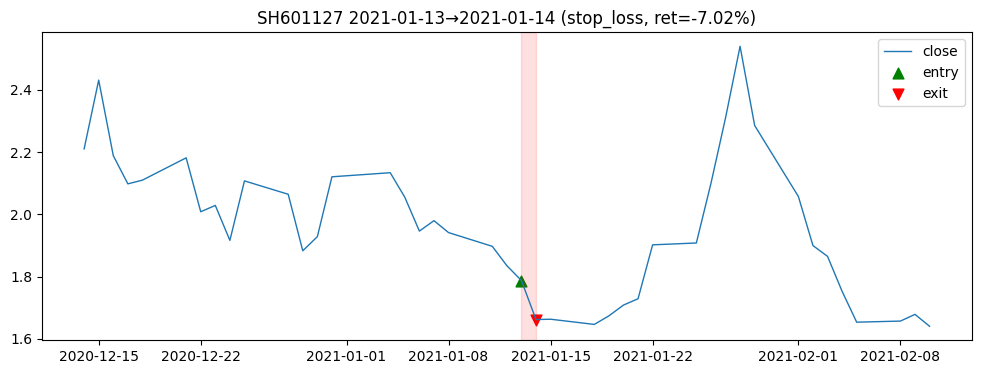

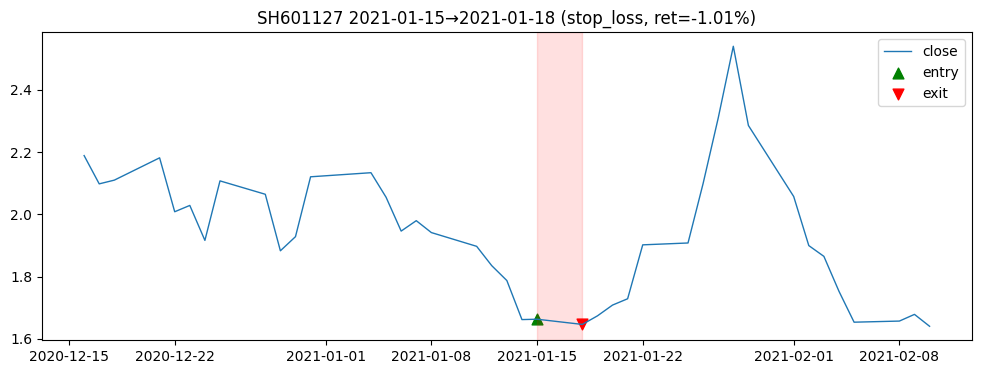

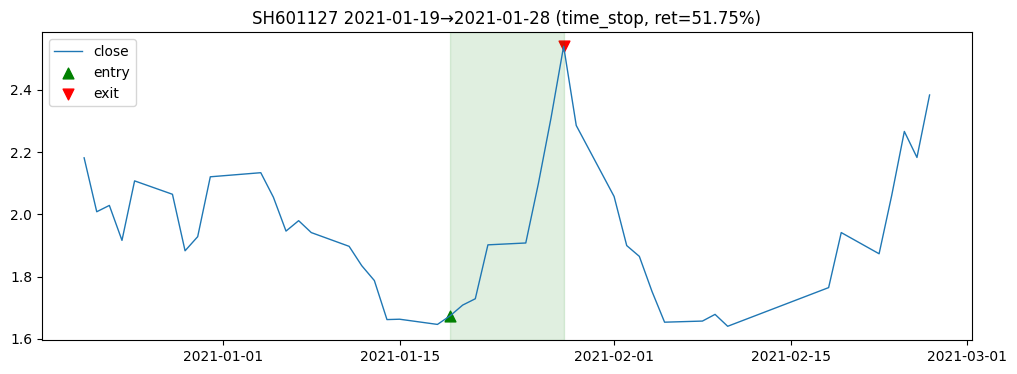

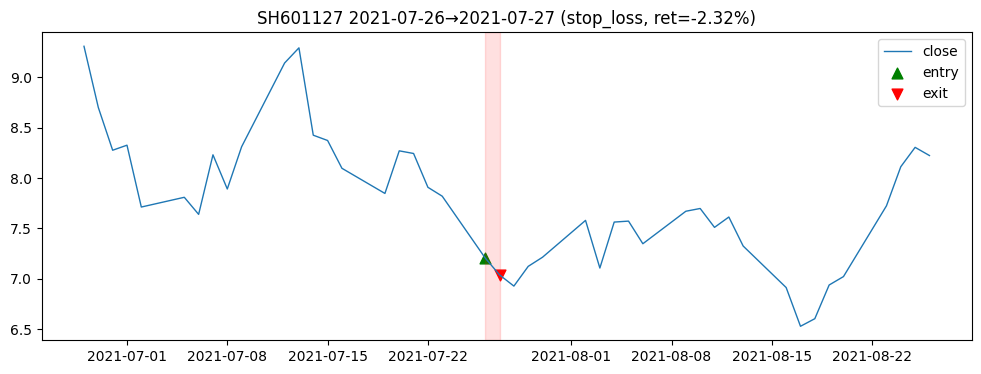

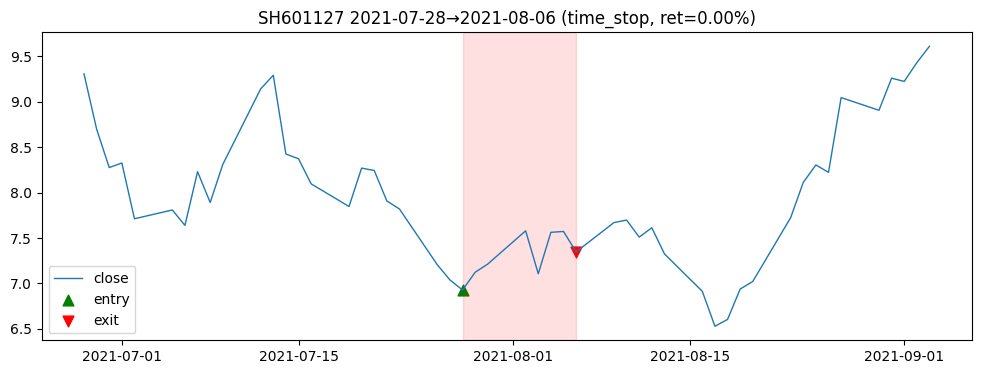

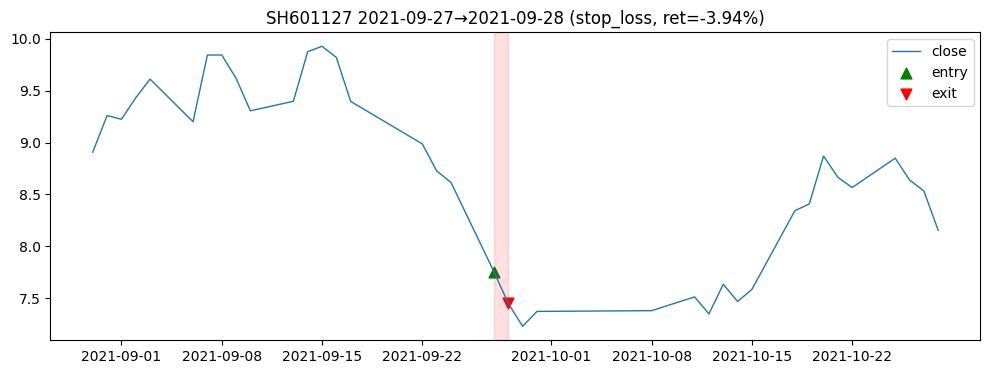

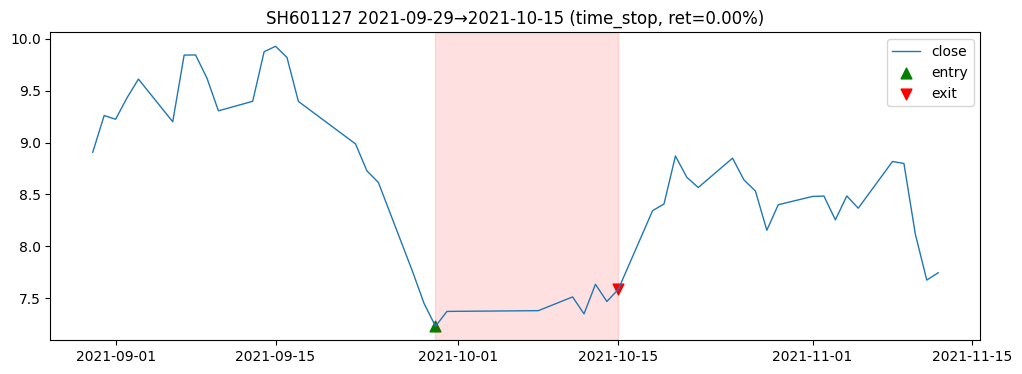

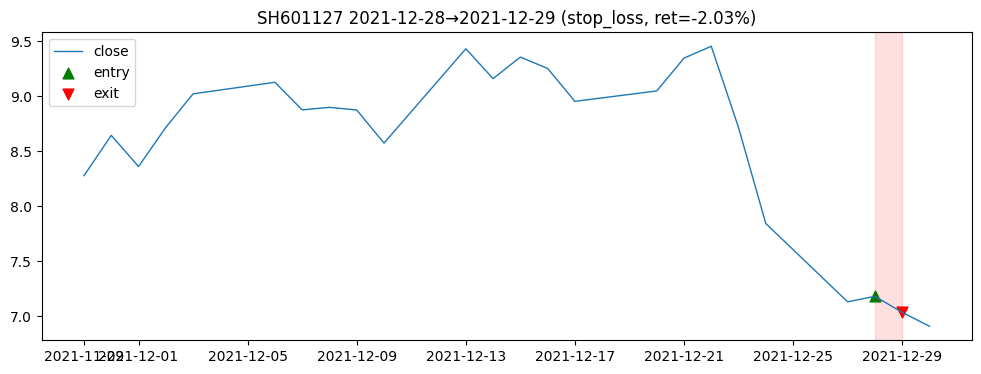

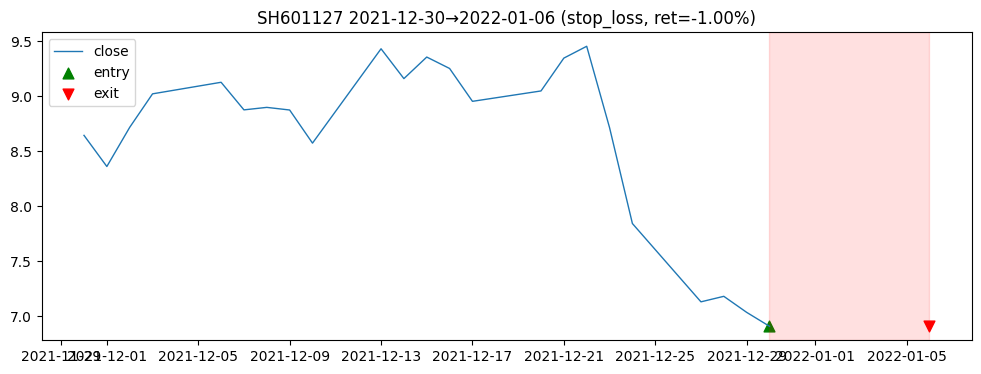

In [18]:
plot_trade_windows(RUN_ID, COMBO, MODE, ticker="SH601127", window_days=30)

In [19]:
from copy import deepcopy

from run.pipeline.stage4_parallel import (
    _simulate_positions_vectorized,
    _calculate_returns_vectorized,
    _compute_metrics_from_returns_dict,
)

def run_one(panel_df, signal_series, cfg):
    panel = panel_df.copy()
    col = "sig"
    panel[col] = signal_series.values
    positions, trades = _simulate_positions_vectorized(panel=panel, signal_columns=[col], cfg=cfg)
    rets = _calculate_returns_vectorized(panel=panel, positions=positions, cfg=cfg)[col]
    metrics = _compute_metrics_from_returns_dict(rets)
    return metrics, trades[col], rets

# 예시: OOS에서 sell 조건만 바꿔가며 비교
base_cfg = cfg  # (네가 쓰는 cfg 객체: run_config에서 로드했든, load_rd_config 했든)
panel_df = oos_panel  # timestamp/ticker/close/high/low + signal 생성에 쓴 컬럼들이 들어있는 DF
signal_series = oos_signal  # bool series (panel_df와 같은 index)

stop_losses = [None, -0.005, -0.01, -0.02]
horizons = [2, 3, 5]
trigger_ops = ["gte", "lte"]

results = []
for sl in stop_losses:
    for h in horizons:
        for op in trigger_ops:
            cfg2 = deepcopy(base_cfg)
            cfg2.stage4.stop_loss_threshold = sl
            cfg2.stage4.horizon_days = h
            cfg2.stage4.trigger_op = op
            cfg2.stage4.trigger_kmin = 10**9
            cfg2.stage4.trigger_kmax = 0
            # trigger_price_field / trigger_op / ref_price_fn 은 이제 의미 없음

            #cfg2.stage4.trigger_kmax = h  # 보통 horizon에 맞춰줌

            m, trades, rets = run_one(panel_df, signal_series, cfg2)
            results.append({
                "stop_loss": sl,
                "horizon": h,
                "trigger_op": op,
                "oos_ir": m["information_ratio"],
                "oos_net_return": m["net_return"],
                "n_trades": len(trades),
            })

import pandas as pd
pd.DataFrame(results).sort_values("oos_ir", ascending=False).head(20)


ModuleNotFoundError: No module named 'run'